In [1]:
# import modules
from PyCROSL.CRO_SL import *
from PyCROSL.AbsObjectiveFunc import *
from PyCROSL.SubstrateReal import *
from PyCROSL.SubstrateInt import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import pandas as pd
import numpy as np
import xarray as xr

from IPython.display import Image
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')
import ipywidgets as widgets

import os
import sys
sys.path.insert(1, '../Modules/')
from EPE_optimisation_fast import optimisation_fast
from EPE_board_visualisation import *

# Step-1 - Feature selection set up

Define the number of feature selection algorithm evaluations.

In [2]:
### TODO ###
region="Cluj-Napoca"
accumulation_time = 3
quantile = 0.90

In [3]:
eval_widget = widgets.IntSlider(
    value=3000,                    # Default value
    min=1000,                      # Minimum duration
    max=10000,                     # Maximum duration  
    step=100,                     # Step size
    description='Number of Evaluations:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

eval_widget

IntSlider(value=3000, description='Number of Evaluations:', layout=Layout(width='400px'), max=10000, min=1000,…

# Step-2 - Load and check predictor data

Inspect the predictor dataset and the definitions of lag time and sequence length.

In [4]:
# check the values
num_eval=eval_widget.value
print ("Number of evaluations to run: ",num_eval)

# define the training and test set
first_train = "1941-03-17"
last_train = "2010-03-17" 
first_test = last_train
last_test = "2024-04-14"


# define the file names
indiv_file = f'Output/optimisation_output_{region}_N{int(quantile*100)}p_neval{num_eval}_ac{accumulation_time}_fast.csv'
solution_file = f'Output/optimisation_output_{region}_N{int(quantile*100)}p_neval{num_eval}_ac{accumulation_time}_fast_sol.csv'

computed_config = os.path.exists(indiv_file)

# check the if the feature selection has been already computed for this evaluation
if computed_config:
    print('Configuration already computed.')
    sol_data = pd.read_csv(indiv_file, index_col=None, sep=' ', header=0)  
else:
    sol_data = pd.DataFrame(columns=['CV', 'Test', 'Sol'])
    sol_data.to_csv(indiv_file, sep=' ', header=sol_data.columns, index=None)

pred_dataframe = pd.read_csv('../DATA/Predictors_dataset_ERA5_weekly_1940_2024_kmean_1993_2016_0.05_clim_1993_2016_pcs_0.01_centroids_id5_AMJ.csv', index_col=0)

Number of evaluations to run:  3000
Configuration already computed.


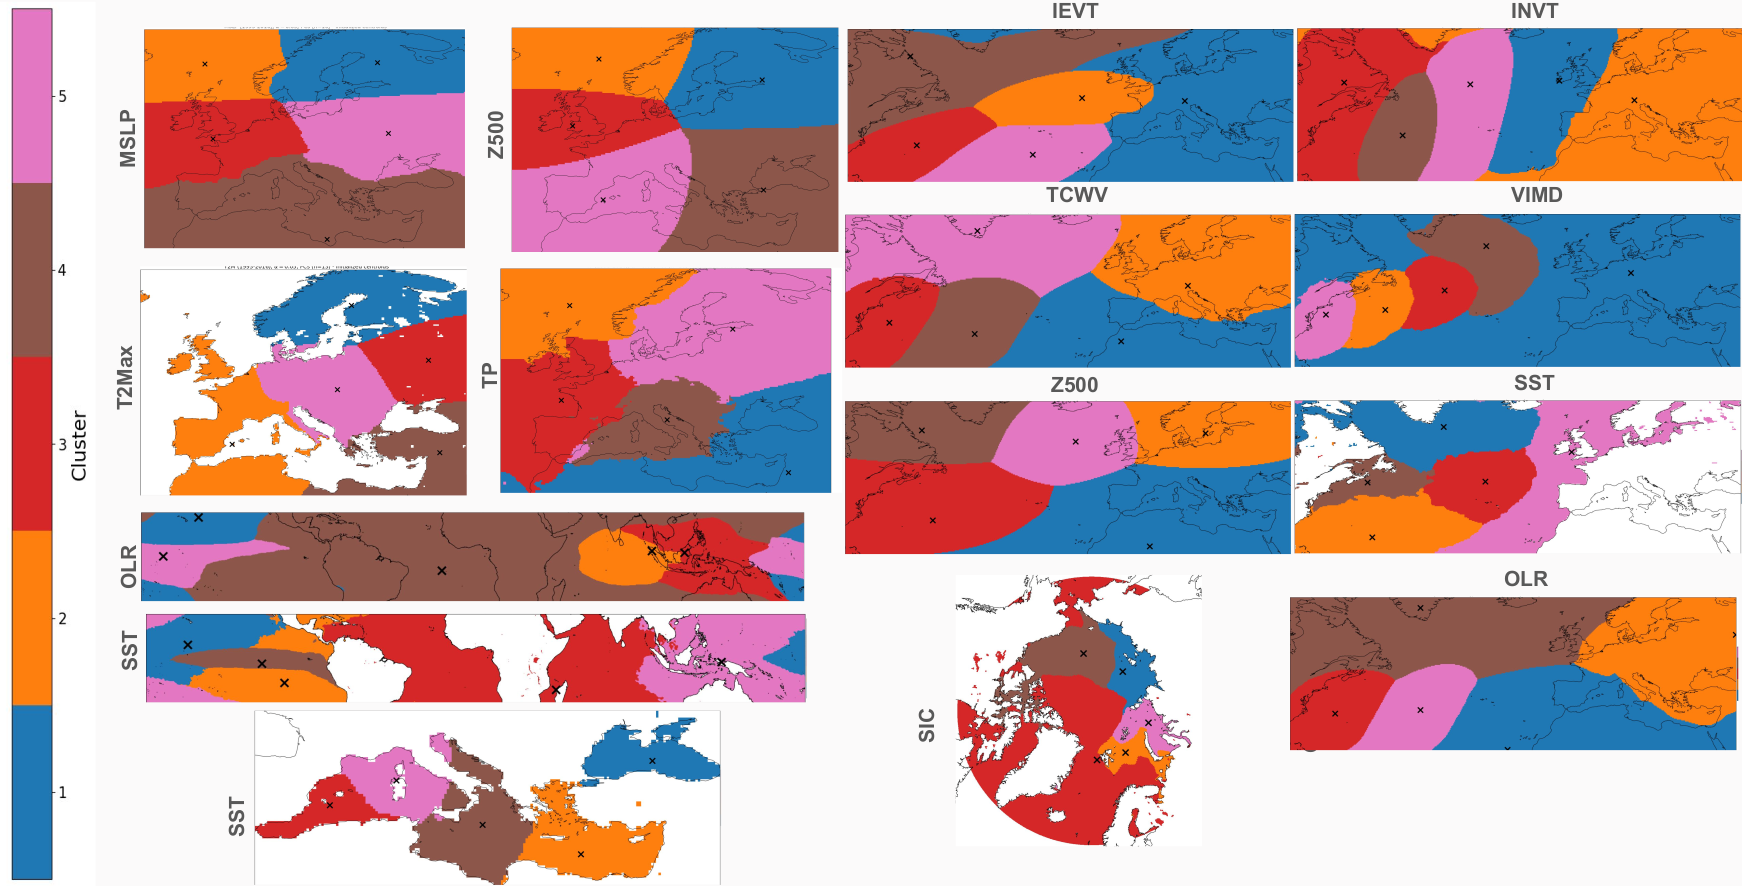

In [5]:
display(Image(filename='../clusters_5.png'))

In [6]:
# check the names of the potential predictors
print ("List of Potential Predictors")
print (pred_dataframe.columns.values)
column_names = pred_dataframe.columns.tolist()


# select the cluster to visualise
show_cluster="IEVT_NA_cluster3"

List of Potential Predictors
['SIC_ARC_cluster1' 'SIC_ARC_cluster2' 'SIC_ARC_cluster3'
 'SIC_ARC_cluster4' 'SIC_ARC_cluster5' 'SST_TR_cluster1' 'SST_TR_cluster2'
 'SST_TR_cluster3' 'SST_TR_cluster4' 'SST_TR_cluster5' 'SST_EU_cluster1'
 'SST_EU_cluster2' 'SST_EU_cluster3' 'SST_EU_cluster4' 'SST_EU_cluster5'
 'TP_EU_cluster1' 'TP_EU_cluster2' 'TP_EU_cluster3' 'TP_EU_cluster4'
 'TP_EU_cluster5' 'T2M_EU_cluster1' 'T2M_EU_cluster2' 'T2M_EU_cluster3'
 'T2M_EU_cluster4' 'T2M_EU_cluster5' 'Z500_EU_cluster1' 'Z500_EU_cluster2'
 'Z500_EU_cluster3' 'Z500_EU_cluster4' 'Z500_EU_cluster5'
 'MSLP_EU_cluster1' 'MSLP_EU_cluster2' 'MSLP_EU_cluster3'
 'MSLP_EU_cluster4' 'MSLP_EU_cluster5' 'OLR_TR_cluster1' 'OLR_TR_cluster2'
 'OLR_TR_cluster3' 'OLR_TR_cluster4' 'OLR_TR_cluster5' 'OLR_NA_cluster1'
 'OLR_NA_cluster2' 'OLR_NA_cluster3' 'OLR_NA_cluster4' 'OLR_NA_cluster5'
 'SST_NA_cluster1' 'SST_NA_cluster2' 'SST_NA_cluster3' 'SST_NA_cluster4'
 'SST_NA_cluster5' 'Z500_NA_cluster1' 'Z500_NA_cluster2'
 'Z500_NA

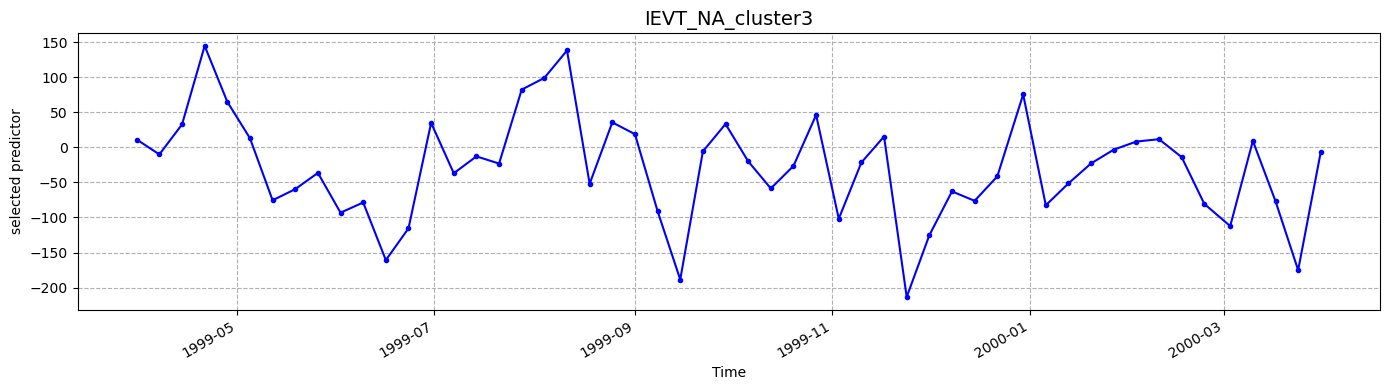

In [7]:
# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

year=2000

# timeseries in mm/day
ts = pred_dataframe[show_cluster].loc["1999-03-31":"2000-03-31"]
ts.index = pd.to_datetime(ts.index)

# plot daily timeseries
ts.plot(ax=ax, color='blue', linewidth=1.5, ls='-', marker='.')

title = f"{ts.name}"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel('selected predictor')
ax.set_xlabel('Time')
ax.grid(ls='--')


plt.tight_layout()
plt.show()

In [8]:
# select the sequence length to visualise
sequence_length_widget = widgets.IntSlider(
    value=2,                    # Default value
    min=0,                      # Minimum duration
    max=8,                     # Maximum duration  
    step=1,                     # Step size
    description='Sequence length:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

sequence_length_widget

IntSlider(value=2, description='Sequence length:', layout=Layout(width='400px'), max=8, style=SliderStyle(desc…

In [9]:
# select the lag time to visualise
final_sequence_widget = widgets.IntSlider(
    value=5,                    # Default value
    min=0,                      # Minimum duration
    max=20,                     # Maximum duration  
    step=1,                     # Step size
    description='Lag time:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

final_sequence_widget

IntSlider(value=5, description='Lag time:', layout=Layout(width='400px'), max=20, style=SliderStyle(descriptio…

In [10]:
# example of possible configuration
sequence_length_ex = sequence_length_widget.value
final_sequence_ex =final_sequence_widget.value
feat_sel_ex = np.where(sequence_length_ex == 0, 0, 1) # 0 or 1 # feature selction

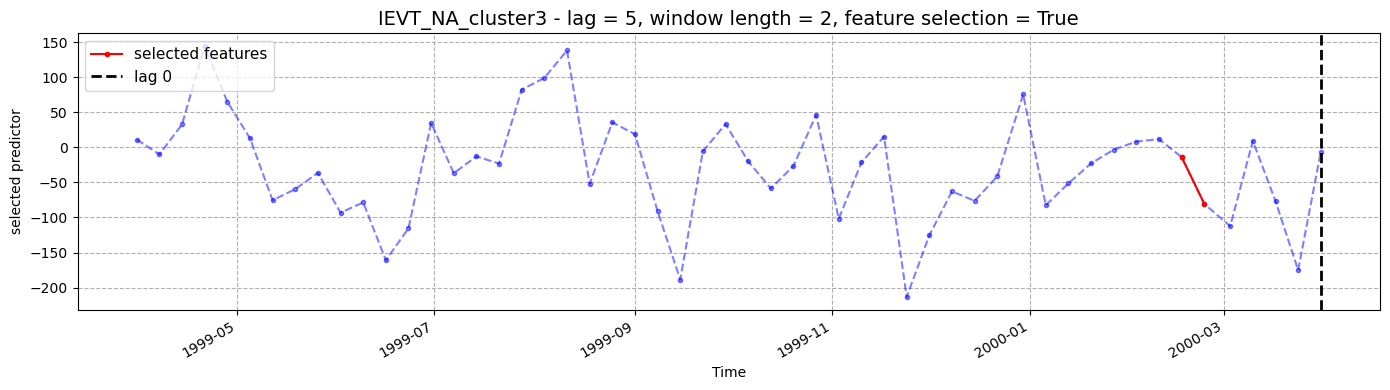

In [11]:
# plot the time series
fig, ax = plt.subplots(figsize=(14,4))



# plot daily timeseries
ts.plot(ax=ax, color='blue', linewidth=1.5, ls='--', marker='.', alpha= 0.5, label='')

if feat_sel_ex == 1:
    ts_selected = ts.iloc[-final_sequence_ex-sequence_length_ex:-final_sequence_ex]
    ts_selected.plot(ax=ax, color='red', linewidth=1.5, ls='-', marker='.', label='selected features')

ax.axvline(ts.index[-1], color='k', linestyle='--', linewidth=2, label = 'lag 0')

title = f"{ts.name} - lag = {final_sequence_ex}, window length = {sequence_length_ex}, feature selection = {str(feat_sel_ex==1)}"
ax.set_title(title, fontsize=14)



# labels, grid, legend
ax.set_ylabel('selected predictor')
ax.set_xlabel('Time')
ax.grid(ls='--')
ax.legend(loc='upper left', fontsize=11)


plt.tight_layout()
plt.show()

# Step-3 - Open Target Dataset

Open the target time series generated in the previous notebook.

In [12]:
# read the csv file
target_dataset = pd.read_csv(f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv", index_col='pred_date')

# define the train index
first_train_index=int(np.argwhere(target_dataset.index==first_train))
last_train_index=int(np.argwhere(target_dataset.index==last_train))

# Step-4 - Feature selection

Run the PCRO-SL (Probabilistic Coral Reef Optimization with Substrate Layers) algorithm for feature selection.

In [13]:
# Useful quantities

# LAG and WINDOW
MAX_LAG = 26
MAX_WINDOW = 8
MAX_SHIFT = MAX_LAG + MAX_WINDOW
NLEN = len(pred_dataframe)
idx_pred = pred_dataframe.index[MAX_SHIFT:]
valid_idx = idx_pred.intersection(target_dataset.index) # Valid indices

X_blocks = []
col_meta = []
col_index = {} # To identify lags
col_id = 0
for var_i, col in enumerate(pred_dataframe.columns):
    s = pred_dataframe[col].to_numpy()
    for lag in range(1, MAX_SHIFT + 1):
        xlag = s[MAX_SHIFT - lag : NLEN - lag]
        X_blocks.append(xlag.reshape(-1, 1))
        col_meta.append((var_i, lag))
        col_index[(var_i, lag)] = col_id 
        col_id += 1

X_full = np.hstack(X_blocks).astype(np.float32)
pos = idx_pred.get_indexer(valid_idx)
X_full = X_full[pos, :]

y_full = target_dataset.reindex(valid_idx)['Target'].to_numpy()

X_train_full = X_full[first_train_index:last_train_index]
X_test_full  = X_full[last_train_index:]
y_train_full = y_full[first_train_index:last_train_index]
y_test_full  = y_full[last_train_index:]

# Avoiding standardization per generation
mu = X_train_full.mean(axis=0)
sigma = X_train_full.std(axis=0)
sigma[sigma == 0] = 1

# Cache to avoid computing repeated solutions
fitness_cache = {}

In [14]:
# Initialize the objective function with size = 3 * number of predictors
objfunc = optimisation_fast(
    size=3*pred_dataframe.shape[1], pred_dataframe=pred_dataframe,
    MAX_LAG=MAX_LAG, MAX_WINDOW=MAX_WINDOW,
    fitness_cache=fitness_cache, col_index=col_index, X_train_full=X_train_full,
    y_train_full=y_train_full, X_test_full=X_test_full, y_test_full=y_test_full, mu=mu, sigma=sigma, indiv_file=indiv_file
)

# Define CRO-SL parameters
params = {
    "popSize": 100,
    "rho": 0.6,
    "Fb": 0.98,
    "Fd": 0.2,
    "Pd": 0.8,
    "k": 3,
    "K": 20,
    "group_subs": True,

    "stop_cond": "Neval",
    "time_limit": 4000.0,
    "Ngen": 10000,
    "Neval": num_eval,
    "fit_target": 1000, 

    "verbose": True,
    "v_timer": 1,
    "Njobs": 1,

    "dynamic": True,
    "dyn_method": "success",
    "dyn_metric": "avg",
    "dyn_steps": 10,
    "prob_amp": 0.01,

    "prob_file": f"prob_history_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "popul_file": f"last_populationN{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "history_file": f"fit_history_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "solution_file": f"best_solution_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "indiv_file": f"indiv_hisotry_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
}

# Define operators for the algorithm
operators = [
    SubstrateInt("BLXalpha", {"F": 0.8}),
    SubstrateInt("Multipoint"),
    SubstrateInt("HS", {"F": 0.7, "Cr": 0.8, "Par": 0.2}),
    SubstrateInt("Xor"),
]

In [15]:
if not computed_config:
    # Initialize and run the optimization algorithm
    cro_alg = CRO_SL(objfunc, operators, params)
    solution, obj_value = cro_alg.optimize()#save_data = False, update_data = False
    # It prints the score for the training set (left) and the test set (rightCompute the number of days with accumulation exceeding the selected quantile.)
    
    # Save final solution
    solution.tofile(solution_file, sep=',')
    print(f"Optimization completed. Best objective value: {obj_value}")
    print(f"Solution saved to {solution_file}")

# Step-5 - Visualisation

Inspect the feature selection results.

In [16]:
print ("Training Score (CV - cross-validation) , Test Score , Solution array")

name = indiv_file
sol_file_av = pd.read_csv(name, index_col=None, sep=' ', header=0)    
num_sims=sol_file_av.shape[0]

print (sol_file_av)

print ("Number of optimisation evaluations: ", sol_file_av.shape[0])

Training Score (CV - cross-validation) , Test Score , Solution array
            CV      Test                                                Sol
0     2.607867  1.638934  [5 4 5 6 1 7 5 1 6 1 7 7 4 1 4 4 2 4 4 4 5 3 1...
1     3.097573  1.584456  [4 5 5 5 2 2 4 5 4 1 1 2 7 3 3 4 1 4 3 5 2 1 7...
2     1.957527  1.381170  [3 1 1 7 3 3 4 7 1 1 6 1 1 2 2 1 6 4 2 4 4 1 6...
3     2.600582  1.569772  [1 7 5 5 5 1 6 6 1 7 4 1 2 5 1 5 1 2 1 6 1 2 6...
4     3.439723  1.809632  [2 4 4 6 2 4 5 4 6 2 1 1 6 1 3 7 2 3 4 1 2 5 6...
...        ...       ...                                                ...
2946  1.082189  0.735542  [ 2.  2.  3.  1.  1.  4.  2.  1.  6.  2.  5.  ...
2947  1.046136  0.845128  [ 4.  2.  3.  1.  1.  4.  4.  2.  2.  3.  5.  ...
2948  1.217610  0.958670  [ 3  2  2  1  1  4  2  8  5  2  5  1  3  3  3 ...
2949  1.118139  0.973983  [ 2.  2.  2.  1.  2.  5.  6.  3.  6.  3.  6.  ...
2950  1.068554  0.881031  [ 2.  2.  5.  1.  1.  4.  3.  1.  6.  2.  5.  ...

[2951 rows x 3 col

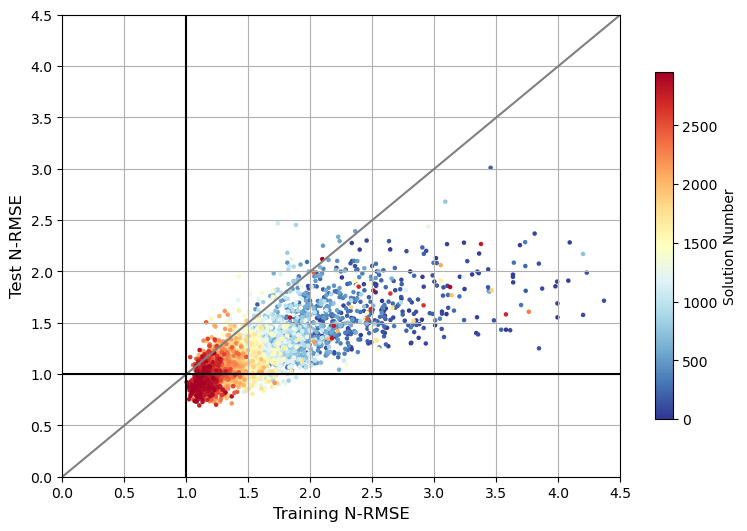

In [17]:
# Plot scatter plot to identify overfitting
scores_data_no_duplicates = sol_file_av.drop_duplicates().reset_index(drop=True)

plt.figure(figsize=(9,6))
plt.scatter(scores_data_no_duplicates['CV'],scores_data_no_duplicates['Test'],c=range(len(scores_data_no_duplicates)),s=5,alpha=1,cmap='RdYlBu_r')

cbar=plt.colorbar(label="Solution Number",shrink=0.75)
cbar.ax.tick_params(labelsize=10)

plt.plot([0,4.5],[0,4.5],ls='-', color='grey')
plt.axhline(y=1,ls='-',lw=1.5,color='black')
plt.axvline(x=1,ls='-',lw=1.5,color='black')

plt.xlabel("Training N-RMSE",fontsize=12)
plt.ylabel("Test N-RMSE",fontsize=12)
plt.xlim([0,4.5])
plt.ylim([0,4.5])

plt.grid()
#plt.savefig(path+'figures/opt_progress_2_{}_{}_at{}_{}{}.png'.format(region, period, accumulation_time, num_eval, sel_iter))
plt.show()

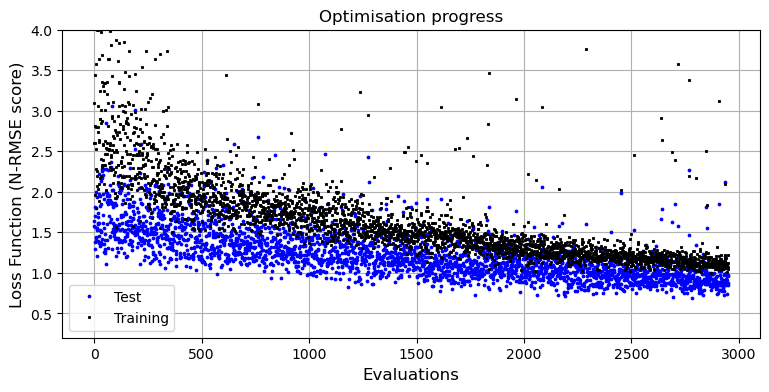

In [18]:
# Plot loss functions during evaluation process 
plt.figure(figsize=(9,4))

plt.plot(scores_data_no_duplicates.index,scores_data_no_duplicates['Test'],'b',marker='o',ms=1.7,lw=0, label = 'Test')
plt.plot(scores_data_no_duplicates.index,scores_data_no_duplicates['CV'],'k',marker='x',ms=1.7,lw=0, label = 'Training')

plt.title("Optimisation progress")
plt.xlabel('Evaluations',fontsize=12)

plt.ylabel('Loss Function (N-RMSE score)',fontsize=12)
plt.ylim([0.2,4])
plt.legend()
plt.grid()

plt.show()

In [19]:
# extract the values of lag_time, sequence_length and feature_selection
array_best = np.fromstring(sol_file_av.Sol[sol_file_av.sort_values(by=['CV'],ascending=True).index[0]].replace('[', '').replace(']', '').replace('\n', ''), dtype=float, sep=' ')
split=int(array_best.shape[0]/3)

sequence_length_best = array_best[0:split]
final_sequence_best = array_best[split:split*2]
feat_sel_best = array_best[split*2:]

In [20]:
# create the board
n_rows = int((sequence_length_best + final_sequence_best).max())+10
n_cols = pred_dataframe.shape[1]
board_best = create_board(n_rows, n_cols, final_sequence_best, sequence_length_best, feat_sel_best)

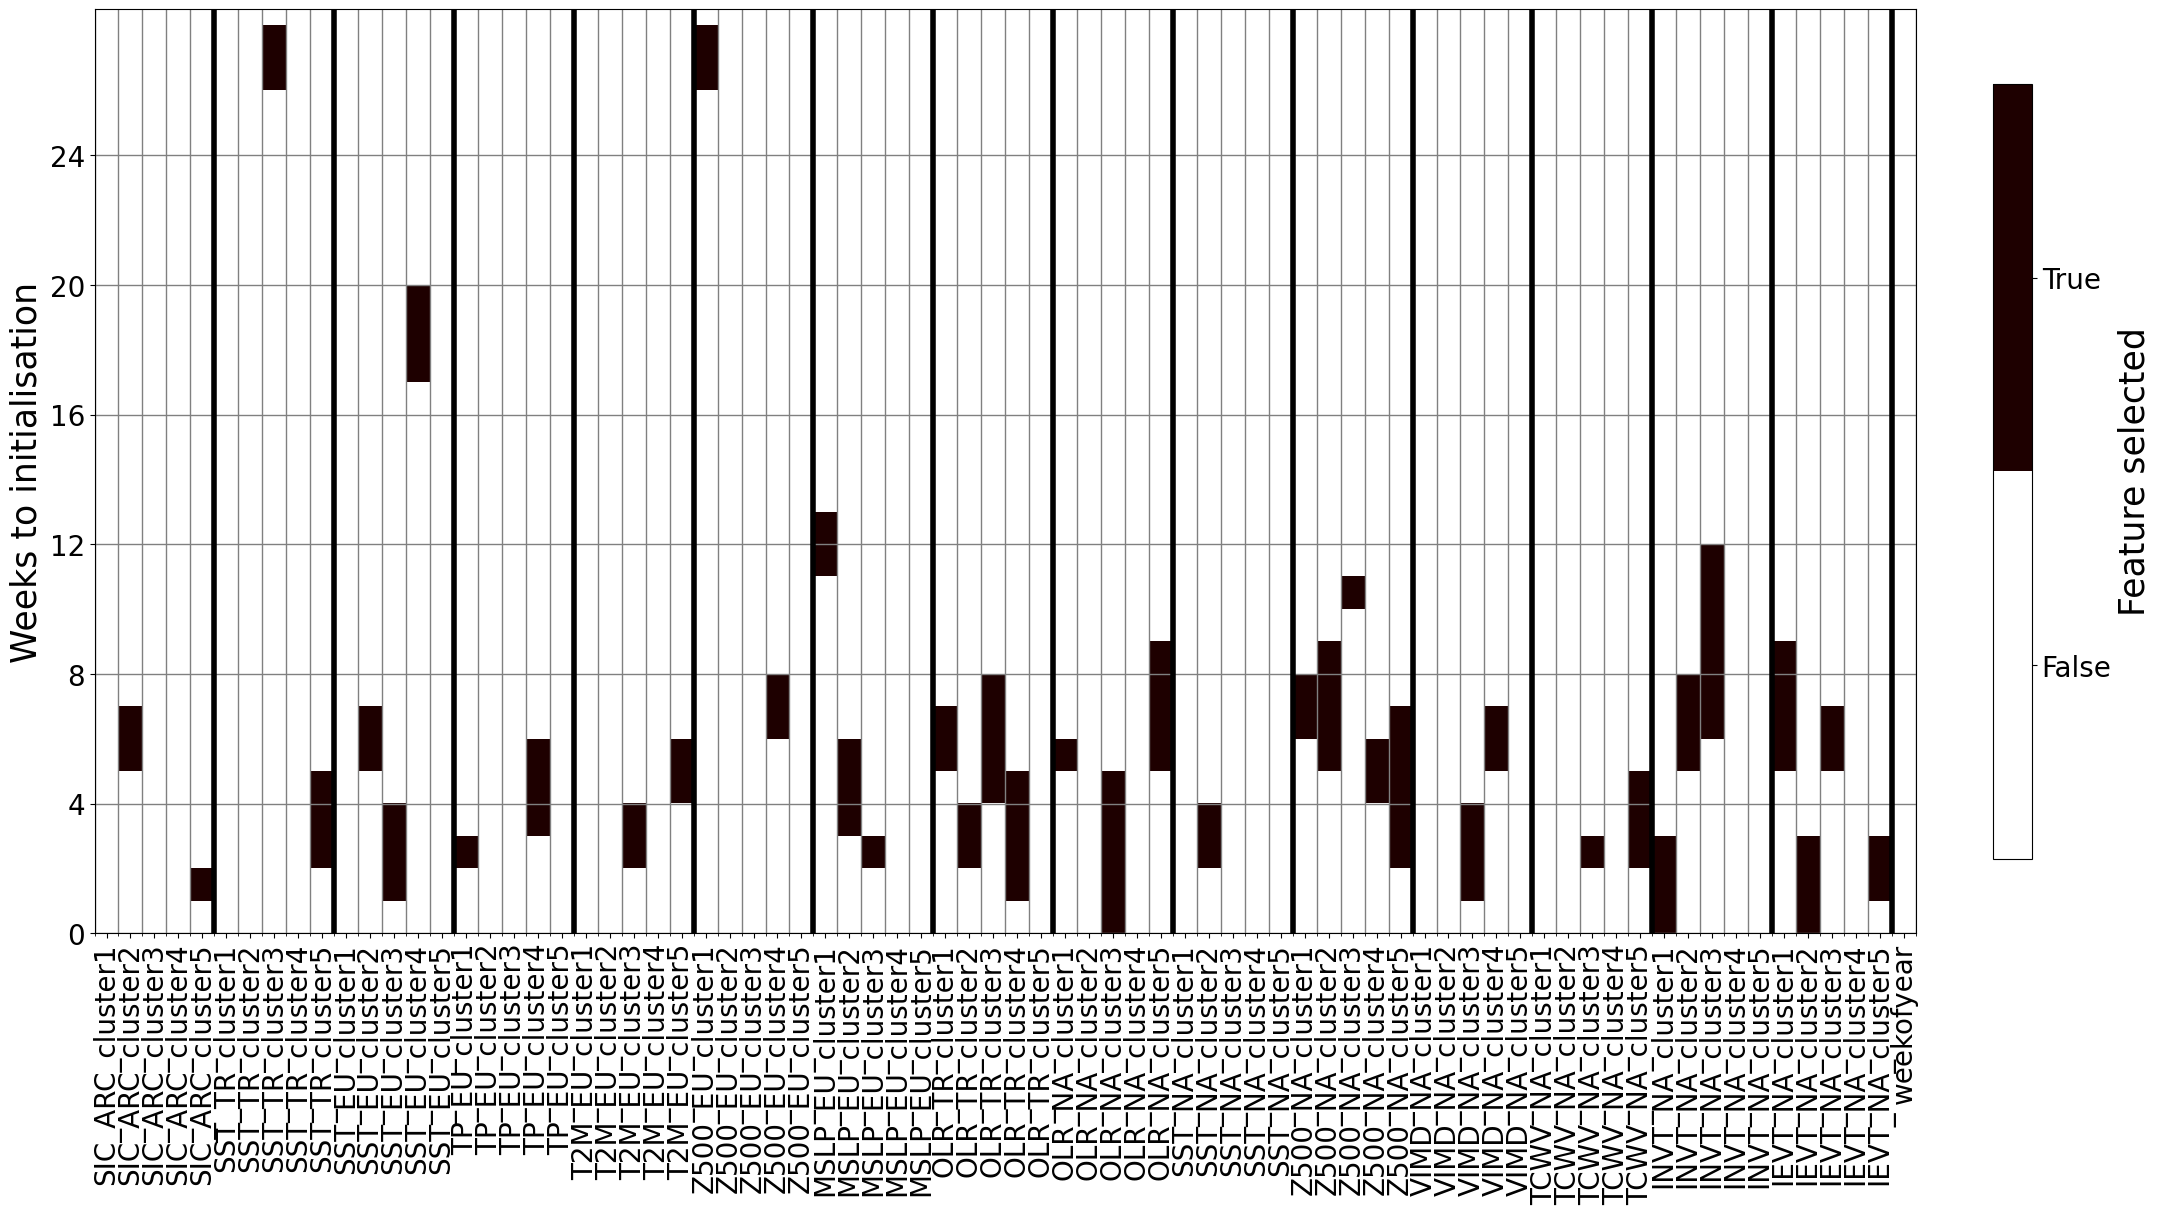

In [21]:
# plot
plot_board(board_best, column_names,True)

In [22]:
#display(Image(filename='../clusters_5.png'))